In [2]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os
import tensorflow as tf
import random

In [3]:
# START FROM HERE!!

raw_image_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/raw_images/'
ground_truth_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/segmentations/'
unet_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/cylinder_niipredictions/'
# unetpp_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/unet++_predictions/'

raw_images = sorted(os.listdir(raw_image_directory))
segmentations = sorted(os.listdir(ground_truth_directory))
unet_predictions = sorted(os.listdir(unet_directory))
# unetpp_predictions = sorted(os.listdir(unetpp_directory))

image_dataset = []
mask_dataset = []
unet_prediction_dataset = []
# unetpp_prediction_dataset = []
image_names = []

for image_name in raw_images:    
    if (image_name.split('.')[1] == 'nii'):
        base_name = image_name.split('.')[0]
        image = nib.load(raw_image_directory+image_name).get_fdata()
        segmentation = nib.load(ground_truth_directory+image_name).get_fdata()
        new_mask = np.copy(segmentation)
        new_mask[segmentation == 1] = 0
        unet = nib.load(unet_directory+image_name).get_fdata()
        # unetpp = nib.load(unetpp_directory+image_name).get_fdata()
        
        image_dataset.append(np.array(image))
        mask_dataset.append(np.array(new_mask))
        unet_prediction_dataset.append(np.array(unet))
        # unetpp_prediction_dataset.append(np.array(unetpp))
        image_names.append(base_name)

In [4]:
num_classes = 7
stats = {}

# allComparisons = {"GroundTruth": mask_dataset, "Unet": unet_prediction_dataset, "Unet++":unetpp_prediction_dataset}
allComparisons = {"GroundTruth": mask_dataset, "Unet": unet_prediction_dataset}
slices = {"Mid-Slice+1":1, "Mid-Slice":0, "Mid-Slice-1":-1}

for i in range(len(image_dataset)):
    image = image_dataset[i]
    image_name = image_names[i]
    mid_slice = image.shape[2]//2
    for slice_label, offset in slices.items():
        row_key = f"{image_name}_{slice_label}"
        stats[row_key] = {}
        for model_name, model_masks in allComparisons.items():
            if model_name == 'GroundTruth':
                for j in range(num_classes-1):
                    mask_class =model_masks[i]==(j+2)
                    slice_data = (mask_class*image)[:,:,mid_slice+offset] 
                    slice_data = slice_data[slice_data!=0]
                    mean = np.mean(slice_data) if slice_data.size>0 else 0
                    std = np.std(slice_data) if slice_data.size>0 else 0
                    stats[row_key][model_name, f"Cylinder {j+1}", "Mean"] = mean
                    stats[row_key][model_name, f"Cylinder {j+1}", "Std"] = std
            else:
                for j in range(num_classes-2):                   
                    if len(model_masks[i].shape) != 3:
                        mask_class = model_masks[i].squeeze(0)
                        mask_class = (mask_class[:,:,j+2,:] > 0.5).astype(int)
                        slice_data = (mask_class*image)[:,:,mid_slice+offset] 
                        slice_data = slice_data[slice_data!=0]
                        mean = np.mean(slice_data) if slice_data.size>0 else 0
                        std = np.std(slice_data) if slice_data.size>0 else 0
                        stats[row_key][model_name, f"Cylinder {j+1}", "Mean"] = mean
                        stats[row_key][model_name, f"Cylinder {j+1}", "Std"] = std
                    else:
                        mask_class = (model_masks[i]==(j+1) > 0.5).astype(int)
                        slice_data = (mask_class*image)[:,:,mid_slice+offset] 
                        slice_data = slice_data[slice_data!=0]
                        mean = np.mean(slice_data) if slice_data.size>0 else 0
                        std = np.std(slice_data) if slice_data.size>0 else 0
                        stats[row_key][model_name, f"Cylinder {j+1}", "Mean"] = mean
                        stats[row_key][model_name, f"Cylinder {j+1}", "Std"] = std

KeyboardInterrupt: 

In [22]:
import pandas as pd

df = pd.DataFrame.from_dict(stats, orient='index')
df.columns = pd.MultiIndex.from_tuples(df.columns, names=['Model', 'Cylinder', 'Stat'])
df.index.name = "Image_Slice"
df = df.drop(columns=[('GroundTruth', 'Cylinder 6', 'Mean'), ('GroundTruth', 'Cylinder 6', 'Std')])
df

Model                                       GroundTruth                       \
Cylinder                                     Cylinder 1           Cylinder 2   
Stat                                               Mean       Std       Mean   
Image_Slice                                                                    
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1       41.316129  5.242204  33.524590   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice         40.333333  7.166816  31.925170   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1       41.094937  8.441750  33.095890   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1        0.000000  0.000000   0.000000   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice          0.000000  0.000000   0.000000   
...                                                 ...       ...        ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice      0.000000  0.000000   0.000000   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1    0.000000  0.000000   0.000000   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1   41.055556  9.830822  31.108108   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice     41.479730  6.489565  30.439189   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice-1   41.162162  6.650598  30.560811   

Model                                                                        \
Cylinder                                               Cylinder 3             
Stat                                               Std       Mean       Std   
Image_Slice                                                                   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1       5.315016  25.000000  4.876862   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice         4.796666  21.632653  4.552164   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1       5.916460  22.713287  3.988835   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1       0.000000   0.000000  0.000000   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice         0.000000   0.000000  0.000000   
...                                                ...        ...       ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice     0.000000   0.000000  0.000000   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1   0.000000   0.000000  0.000000   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1  10.306214  20.858108  4.753392   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice     9.044355  21.006757  4.855335   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice-1   7.745292  20.216216  5.035738   

Model                                                                        \
Cylinder                                    Cylinder 4           Cylinder 5   
Stat                                              Mean       Std       Mean   
Image_Slice                                                                   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1      16.512821  7.062136   9.156522   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice        14.671429  2.844651   3.573643   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1      12.957447  3.956989   0.623656   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1       0.000000  0.000000   0.000000   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice         0.000000  0.000000   0.000000   
...                                                ...       ...        ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice     0.000000  0.000000   0.000000   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1   0.000000  0.000000   0.000000   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1  11.436364  7.655690  -1.149533   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice    11.830303  7.445661  -0.262500   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice-1  12.347305  7.694720  -0.384615   

Model                                                       Unet            \
Cylinder                                              Cylinder 1             
Stat                                              Std       Mean       Std   
Image_Slice                                                                  
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1      4.713701  40.885906  4.708311   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice

In [23]:
gt_df = df.xs('GroundTruth', axis=1, level='Model')
unet_df = df.xs('Unet', axis=1, level='Model')

gtAllZero = (gt_df==0).all(axis=1)
gtAllNonZero = (gt_df!=0).all(axis=1)
unetAllZero = (unet_df==0).all(axis=1)
unetAllNonZero = (unet_df!=0).all(axis=1)
df = df[(gtAllNonZero & unetAllNonZero) | (gtAllZero & unetAllZero)]
df

Model                                       GroundTruth                       \
Cylinder                                     Cylinder 1           Cylinder 2   
Stat                                               Mean       Std       Mean   
Image_Slice                                                                    
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1       41.316129  5.242204  33.524590   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice         40.333333  7.166816  31.925170   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1       41.094937  8.441750  33.095890   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1        0.000000  0.000000   0.000000   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice          0.000000  0.000000   0.000000   
...                                                 ...       ...        ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice      0.000000  0.000000   0.000000   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1    0.000000  0.000000   0.000000   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1   41.055556  9.830822  31.108108   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice     41.479730  6.489565  30.439189   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice-1   41.162162  6.650598  30.560811   

Model                                                                        \
Cylinder                                               Cylinder 3             
Stat                                               Std       Mean       Std   
Image_Slice                                                                   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1       5.315016  25.000000  4.876862   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice         4.796666  21.632653  4.552164   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1       5.916460  22.713287  3.988835   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1       0.000000   0.000000  0.000000   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice         0.000000   0.000000  0.000000   
...                                                ...        ...       ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice     0.000000   0.000000  0.000000   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1   0.000000   0.000000  0.000000   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1  10.306214  20.858108  4.753392   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice     9.044355  21.006757  4.855335   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice-1   7.745292  20.216216  5.035738   

Model                                                                        \
Cylinder                                    Cylinder 4           Cylinder 5   
Stat                                              Mean       Std       Mean   
Image_Slice                                                                   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1      16.512821  7.062136   9.156522   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice        14.671429  2.844651   3.573643   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1      12.957447  3.956989   0.623656   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1       0.000000  0.000000   0.000000   
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice         0.000000  0.000000   0.000000   
...                                                ...       ...        ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice     0.000000  0.000000   0.000000   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1   0.000000  0.000000   0.000000   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1  11.436364  7.655690  -1.149533   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice    11.830303  7.445661  -0.262500   
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice-1  12.347305  7.694720  -0.384615   

Model                                                       Unet            \
Cylinder                                              Cylinder 1             
Stat                                              Std       Mean       Std   
Image_Slice                                                                  
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1      4.713701  40.885906  4.708311   
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice

In [24]:
# Save DataFrame to an Excel file
df.to_excel('stats4_dataframe.xlsx', index=True)  # Include index (file names)

In [1]:
import pandas as pd

all_data = pd.read_excel('stats4_dataframe.xlsx')
all_data = all_data[3:]
all_data.columns = (['image_name',
'ground_truth_1_mean', 'ground_truth_1_std', 
'ground_truth_2_mean', 'ground_truth_2_std', 
'ground_truth_3_mean', 'ground_truth_3_std', 
'ground_truth_4_mean', 'ground_truth_4_std', 
'ground_truth_5_mean', 'ground_truth_5_std',
'unet_1_mean', 'unet_1_std',
'unet_2_mean', 'unet_2_std',
'unet_3_mean', 'unet_3_std',
'unet_4_mean', 'unet_4_std',
'unet_5_mean', 'unet_5_std',])
all_data['unet_difference_1'] = all_data['unet_1_mean'] - all_data['ground_truth_1_mean']
all_data['unet_difference_2'] = all_data['unet_2_mean'] - all_data['ground_truth_2_mean']
all_data['unet_difference_3'] = all_data['unet_3_mean'] - all_data['ground_truth_3_mean']
all_data['unet_difference_4'] = all_data['unet_4_mean'] - all_data['ground_truth_4_mean']
all_data['unet_difference_5'] = all_data['unet_5_mean'] - all_data['ground_truth_5_mean']
all_data['unet_std_difference_1'] = all_data['unet_1_std'] - all_data['ground_truth_1_std']
all_data['unet_std_difference_2'] = all_data['unet_2_std'] - all_data['ground_truth_2_std']
all_data['unet_std_difference_3'] = all_data['unet_3_std'] - all_data['ground_truth_3_std']
all_data['unet_std_difference_4'] = all_data['unet_4_std'] - all_data['ground_truth_4_std']
all_data['unet_std_difference_5'] = all_data['unet_5_std'] - all_data['ground_truth_5_std']
all_data['unet_average_1'] = (all_data['unet_1_mean'] + all_data['ground_truth_1_mean']) /2
all_data['unet_average_2'] = (all_data['unet_2_mean'] + all_data['ground_truth_2_mean']) /2
all_data['unet_average_3'] = (all_data['unet_3_mean'] + all_data['ground_truth_3_mean']) /2
all_data['unet_average_4'] = (all_data['unet_4_mean'] + all_data['ground_truth_4_mean']) /2
all_data['unet_average_5'] = (all_data['unet_5_mean'] + all_data['ground_truth_5_mean']) /2

differences = all_data[['image_name', 'unet_difference_1', 'unet_difference_2', 'unet_difference_3', 'unet_difference_4', 'unet_difference_5', 'unet_std_difference_1', 'unet_std_difference_2', 'unet_std_difference_3', 'unet_std_difference_4', 'unet_std_difference_5', 'unet_average_1', 'unet_average_2', 'unet_average_3', 'unet_average_4', 'unet_average_5']]
differences.set_index('image_name', inplace=True)
differences

,unet_difference_1,unet_difference_2,unet_difference_3,unet_difference_4,unet_difference_5,unet_std_difference_1,unet_std_difference_2,unet_std_difference_3,unet_std_difference_4,unet_std_difference_5,unet_average_1,unet_average_2,unet_average_3,unet_average_4,unet_average_5
image_name,,,,,,,,,,,,,,,
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1,-0.430223,-1.269116,-0.895105,0.731454,-0.536687,-0.533894,1.414404,-1.717431,0.194439,0.469323,41.101018,32.890032,24.552448,16.878548,8.888178
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice,-0.402299,-0.646599,0.344446,-0.049206,-0.295072,-2.104916,-0.875901,-1.744145,-0.265916,0.692505,40.132184,31.601871,21.804876,14.646825,3.426107
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice-1,-0.015227,-0.6197,0.419526,0.130788,-0.290323,-4.127867,-0.570811,-0.673692,-0.013509,-0.046903,41.087323,32.78604,22.92305,13.022841,0.478495
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice+1,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
A21_02_FatFrac_2D_FAM_BH_18_Mid-Slice,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
A21_19_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice-1,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1,0.052553,-0.114731,-0.119853,0.663015,0.0,-3.108396,-0.006406,0.203328,-0.487606,0.0,41.081832,31.050743,20.798182,11.767871,-1.149533


In [2]:
# cylinder_1 = differences[['unet_difference_1']]
# cylinder_2 = differences[['unet_difference_2']]
# cylinder_3 = differences[['unet_difference_3']]
# cylinder_4 = differences[['unet_difference_4']]
# cylinder_5 = differences[['unet_difference_5']]

# upper_outliers_1 = (cylinder_1 < 2*differences['unet_difference_1'].std()+differences['unet_difference_1'].mean()).all(axis=1)
# lower_outliers_1 = (cylinder_1 > differences['unet_difference_1'].mean()-(2*differences['unet_difference_1'].std())).all(axis=1)

# upper_outliers_2 = (cylinder_2 < 2*differences['unet_difference_2'].std()+differences['unet_difference_2'].mean()).all(axis=1)
# lower_outliers_2 = (cylinder_2 > differences['unet_difference_2'].mean()-(2*differences['unet_difference_2'].std())).all(axis=1)

# upper_outliers_3 = (cylinder_3 < 2*differences['unet_difference_3'].std()+differences['unet_difference_3'].mean()).all(axis=1)
# lower_outliers_3 = (cylinder_3 > differences['unet_difference_3'].mean()-(2*differences['unet_difference_3'].std())).all(axis=1)

# upper_outliers_4 = (cylinder_4 < 2*differences['unet_difference_4'].std()+differences['unet_difference_4'].mean()).all(axis=1)
# lower_outliers_4 = (cylinder_4 > differences['unet_difference_4'].mean()-(2*differences['unet_difference_4'].std())).all(axis=1)

# upper_outliers_5 = (cylinder_5 < 2*differences['unet_difference_5'].std()+differences['unet_difference_5'].mean()).all(axis=1)
# lower_outliers_5 = (cylinder_5 > differences['unet_difference_5'].mean()-(2*differences['unet_difference_5'].std())).all(axis=1)


# cylinder_1_avg = differences[['unet_average_1']]
# cylinder_2_avg = differences[['unet_average_2']]
# cylinder_3_avg = differences[['unet_average_3']]
# cylinder_4_avg = differences[['unet_average_4']]
# cylinder_5_avg = differences[['unet_average_5']]

# artifacts = ((cylinder_1_avg < 60) | (cylinder_2_avg < 50) | (cylinder_3_avg < 50) | (cylinder_4_avg < 40) | (cylinder_5_avg < 40)).any(axis=1)


# differences = differences[(upper_outliers_1 & lower_outliers_1)]
# differences = differences[(upper_outliers_2 & lower_outliers_2)]
# differences = differences[(upper_outliers_3 & lower_outliers_3)]
# differences = differences[(upper_outliers_4 & lower_outliers_4)]
# differences = differences[(upper_outliers_5 & lower_outliers_5)]
# differences = differences[artifacts]

# differences

# Extract single-column Series instead of DataFrame for easier comparisons
c1 = differences['unet_difference_1']
c2 = differences['unet_difference_2']
c3 = differences['unet_difference_3']
c4 = differences['unet_difference_4']
c5 = differences['unet_difference_5']

c1_avg = differences['unet_average_1']
c2_avg = differences['unet_average_2']
c3_avg = differences['unet_average_3']
c4_avg = differences['unet_average_4']
c5_avg = differences['unet_average_5']

# Define bounds for outlier detection ±2 std
def in_bounds(series):
    mean = series.mean()
    std = series.std()
    return (series > (mean - 2*std)) & (series < (mean + 2*std))

# Create masks for each cylinder
mask_1 = in_bounds(c1)
mask_2 = in_bounds(c2)
mask_3 = in_bounds(c3)
mask_4 = in_bounds(c4)
mask_5 = in_bounds(c5)

# Combine outlier masks (all must be True to keep row)
combined_mask = mask_1 & mask_2 & mask_3 & mask_4 & mask_5

# Create artifact mask (True where any of the conditions is True)
artifact_mask = ( (c1_avg < 50) & (c2_avg < 40) & (c3_avg < 30) & (c4_avg < 20) & (c5_avg < 10) )

# Final mask: keep rows that are *within bounds* AND flagged as artifact
final_mask = combined_mask & artifact_mask

# Filter differences once
differences = differences[final_mask]

In [3]:
differences.sort_values(by='unet_average_5', ascending=False)

,unet_difference_1,unet_difference_2,unet_difference_3,unet_difference_4,unet_difference_5,unet_std_difference_1,unet_std_difference_2,unet_std_difference_3,unet_std_difference_4,unet_std_difference_5,unet_average_1,unet_average_2,unet_average_3,unet_average_4,unet_average_5
image_name,,,,,,,,,,,,,,,
A21_12_FatFrac_2D_FAM_BH_14_Mid-Slice,-0.934011,-0.66722,-0.031234,-0.428022,0.046939,-1.118687,0.86849,0.146098,0.221073,0.256377,41.627589,32.023533,23.072221,15.821703,9.327524
A21_02_FatFrac_2D_FAM_BH_14_Mid-Slice+1,-0.430223,-1.269116,-0.895105,0.731454,-0.536687,-0.533894,1.414404,-1.717431,0.194439,0.469323,41.101018,32.890032,24.552448,16.878548,8.888178
A21_15_New_FatFrac_IDEAL_IQ_PDFF_24_Mid-Slice+1,0.582471,-1.256757,0.680846,-3.075097,-0.605561,-0.551472,0.632072,0.334451,-3.167872,0.052704,41.595289,36.621622,21.796563,17.149952,7.569014
A21_02_FatFrac_IDEAL_IQ_PDFF_22_Mid-Slice+1,-0.999507,-0.34368,-0.291964,0.159596,-0.234162,-1.70586,-0.113871,-0.341233,-0.274987,-0.272522,41.324571,28.212776,22.014732,9.968687,5.265433
A21_02_FatFrac_IDEAL_IQ_PDFF_11_Mid-Slice-1,-1.148798,-2.259755,-0.188876,-0.154321,0.053188,-1.16617,-1.984383,0.558882,-0.005922,-0.042944,40.363873,33.944447,21.055222,15.342593,5.114432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A21_15_New_FatFrac_2D_FAM_BH_16_Mid-Slice+1,0.090917,-0.366739,-0.482943,-0.52319,0.146491,-0.843021,0.458447,0.34659,0.551144,0.461519,42.410324,33.080144,23.444479,11.74667,-0.989912
A21_31_FatFrac_3D_Iron_Quant_17_Mid-Slice+1,0.052553,-0.114731,-0.119853,0.663015,0.0,-3.108396,-0.006406,0.203328,-0.487606,0.0,41.081832,31.050743,20.798182,11.767871,-1.149533
A21_09_FatFrac_3D_Iron_Quant_13_Mid-Slice,0.904745,-1.51851,1.167811,-0.392826,-0.125762,-1.943963,-0.551341,-2.170733,0.072061,-0.622951,39.75088,29.868844,19.51779,10.473009,-1.343369


In [4]:
filtered = []

for name in differences.index:
    filtered.append('_'.join(name.split('_')[:-1]))

filtered

['A21_02_FatFrac_2D_FAM_BH_14',
 'A21_02_FatFrac_2D_FAM_BH_14',
 'A21_02_FatFrac_2D_FAM_BH_14',
 'A21_02_FatFrac_2D_FAM_BH_18',
 'A21_02_FatFrac_2D_FAM_BH_18',
 'A21_02_FatFrac_2D_FAM_BH_18',
 'A21_02_FatFrac_IDEAL_IQ_PDFF_11',
 'A21_02_FatFrac_IDEAL_IQ_PDFF_22',
 'A21_02_FatFrac_IDEAL_IQ_PDFF_22',
 'A21_02_FatFrac_IDEAL_IQ_PDFF_22',
 'A21_03_FatFrac_2D_FAM_BH_13',
 'A21_03_FatFrac_2D_FAM_BH_13',
 'A21_03_FatFrac_2D_FAM_BH_13',
 'A21_03_FatFrac_2D_FAM_BH_17',
 'A21_03_FatFrac_2D_FAM_BH_17',
 'A21_03_FatFrac_2D_FAM_BH_17',
 'A21_03_FatFrac_3D_Iron_Quant_12',
 'A21_03_FatFrac_3D_Iron_Quant_12',
 'A21_03_FatFrac_3D_Iron_Quant_12',
 'A21_03_FatFrac_3D_Iron_Quant_18',
 'A21_03_FatFrac_3D_Iron_Quant_18',
 'A21_03_FatFrac_3D_Iron_Quant_18',
 'A21_09_FatFrac_2D_FAM_16',
 'A21_09_FatFrac_2D_FAM_16',
 'A21_09_FatFrac_2D_FAM_16',
 'A21_09_FatFrac_2D_FAM_20',
 'A21_09_FatFrac_2D_FAM_20',
 'A21_09_FatFrac_2D_FAM_BH_15',
 'A21_09_FatFrac_2D_FAM_BH_15',
 'A21_09_FatFrac_2D_FAM_BH_15',
 'A21_09_FatFra

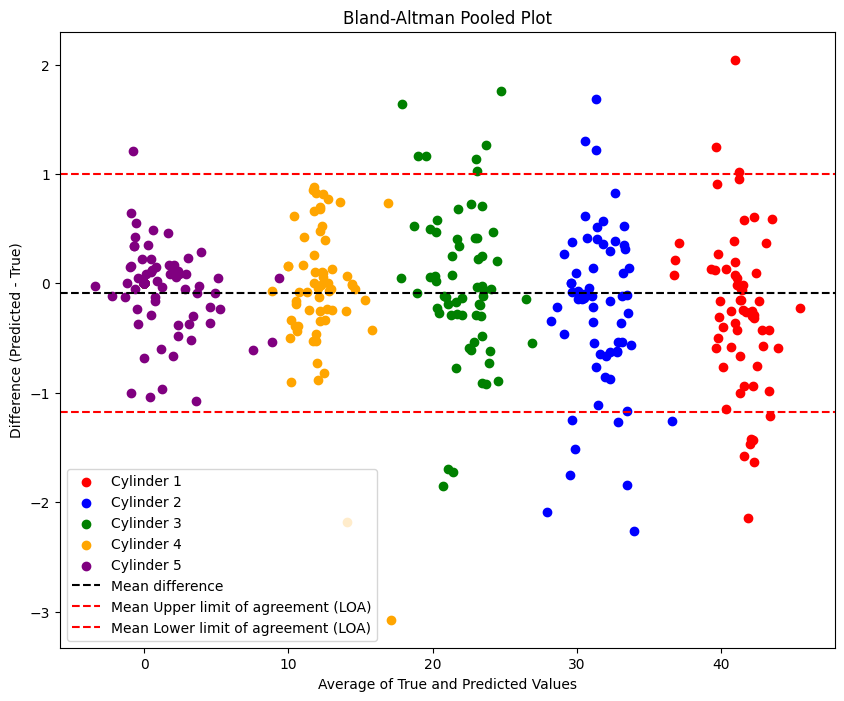

In [111]:
mean_difference1 = differences['unet_difference_1'].mean()
std_difference1 = differences['unet_difference_1'].std()

mean_difference2 = differences['unet_difference_2'].mean()
std_difference2 = differences['unet_difference_2'].std()

mean_difference3 = differences['unet_difference_3'].mean()
std_difference3 = differences['unet_difference_3'].std()

mean_difference4 = differences['unet_difference_4'].mean()
std_difference4 = differences['unet_difference_4'].std()

mean_difference5 = differences['unet_difference_5'].mean()
std_difference5 = differences['unet_difference_5'].std()

loa_upper1 = mean_difference1 + 1.96 * std_difference1
loa_lower1 = mean_difference1 - 1.96 * std_difference1

loa_upper2 = mean_difference2 + 1.96 * std_difference2
loa_lower2 = mean_difference2 - 1.96 * std_difference2

loa_upper3 = mean_difference3 + 1.96 * std_difference3
loa_lower3 = mean_difference3 - 1.96 * std_difference3

loa_upper4 = mean_difference4 + 1.96 * std_difference4
loa_lower4 = mean_difference4 - 1.96 * std_difference4

loa_upper5 = mean_difference5 + 1.96 * std_difference5
loa_lower5 = mean_difference5 - 1.96 * std_difference5

mean_difference = (mean_difference1 + mean_difference2 + mean_difference3 + mean_difference4 + mean_difference5)/5
mean_loa_upper = (loa_upper1 + loa_upper2 + loa_upper3 + loa_upper4 + loa_upper5)/5
mean_loa_lower = (loa_lower1 + loa_lower2 + loa_lower3 + loa_lower4 + loa_lower5)/5

plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_1'], differences['unet_difference_1'], color='red', label='Cylinder 1')
plt.scatter(differences['unet_average_2'], differences['unet_difference_2'], color='blue', label='Cylinder 2')
plt.scatter(differences['unet_average_3'], differences['unet_difference_3'], color='green', label='Cylinder 3')
plt.scatter(differences['unet_average_4'], differences['unet_difference_4'], color='orange', label='Cylinder 4')
plt.scatter(differences['unet_average_5'], differences['unet_difference_5'], color='purple', label='Cylinder 5')
plt.axhline(y=mean_difference, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=mean_loa_upper, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=mean_loa_lower, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Pooled Plot')
plt.legend()
plt.show()

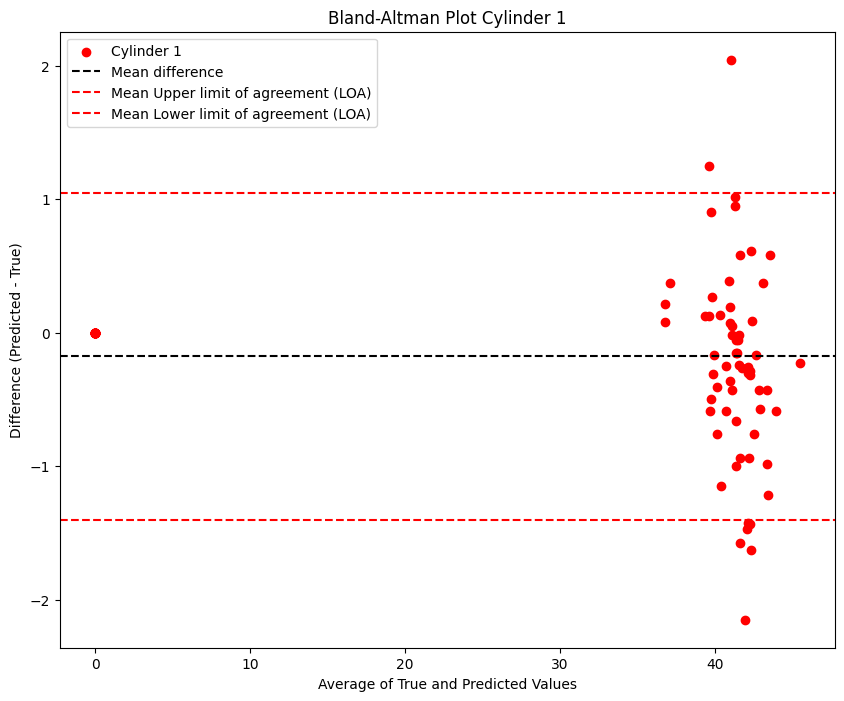

In [112]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_1'], differences['unet_difference_1'], color='red', label='Cylinder 1')
plt.axhline(y=mean_difference1, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper1, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower1, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 1')
plt.legend()
plt.show()

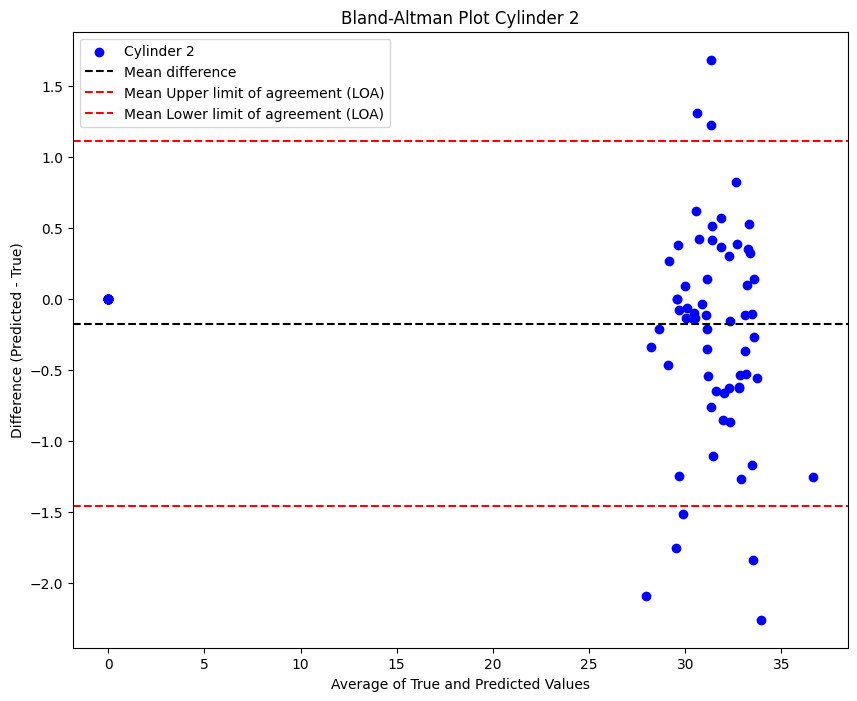

In [113]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_2'], differences['unet_difference_2'], color='blue', label='Cylinder 2')
plt.axhline(y=mean_difference2, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper2, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower2, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 2')
plt.legend()
plt.show()

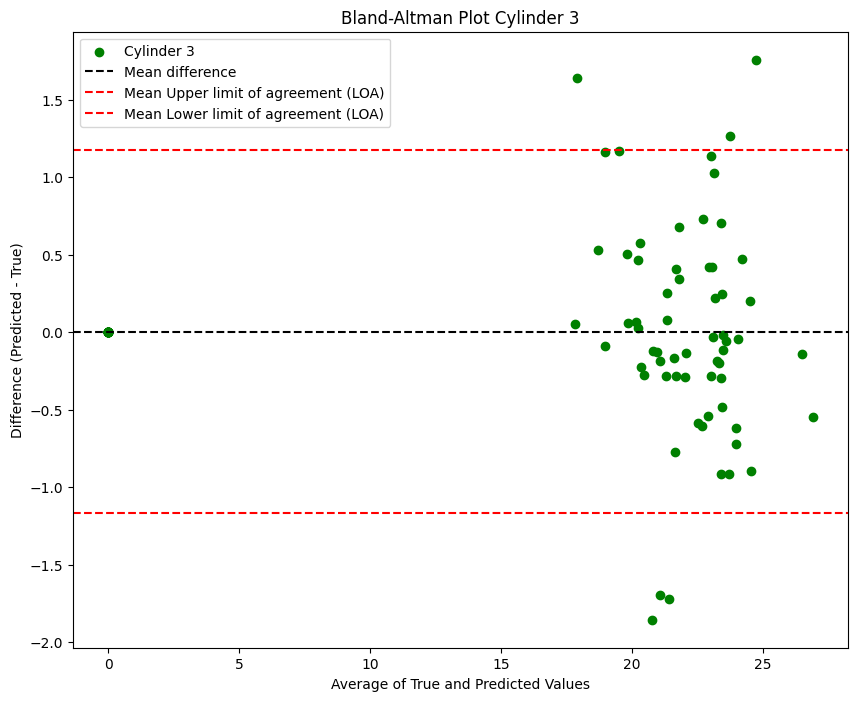

In [114]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_3'], differences['unet_difference_3'], color='green', label='Cylinder 3')
plt.axhline(y=mean_difference3, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper3, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower3, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 3')
plt.legend()
plt.show()

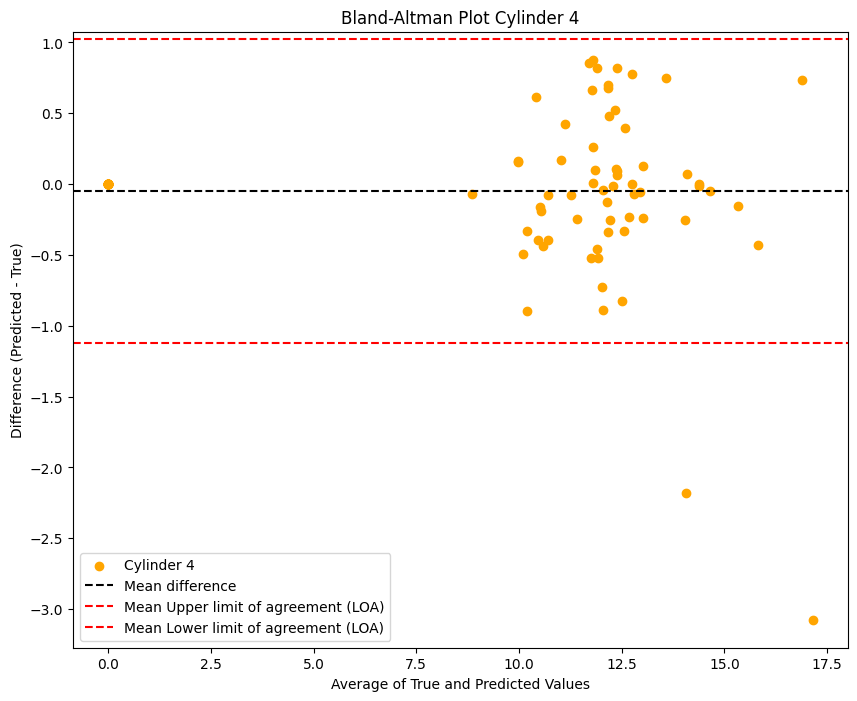

In [115]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_4'], differences['unet_difference_4'], color='orange', label='Cylinder 4')
plt.axhline(y=mean_difference4, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper4, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower4, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 4')
plt.legend()
plt.show()

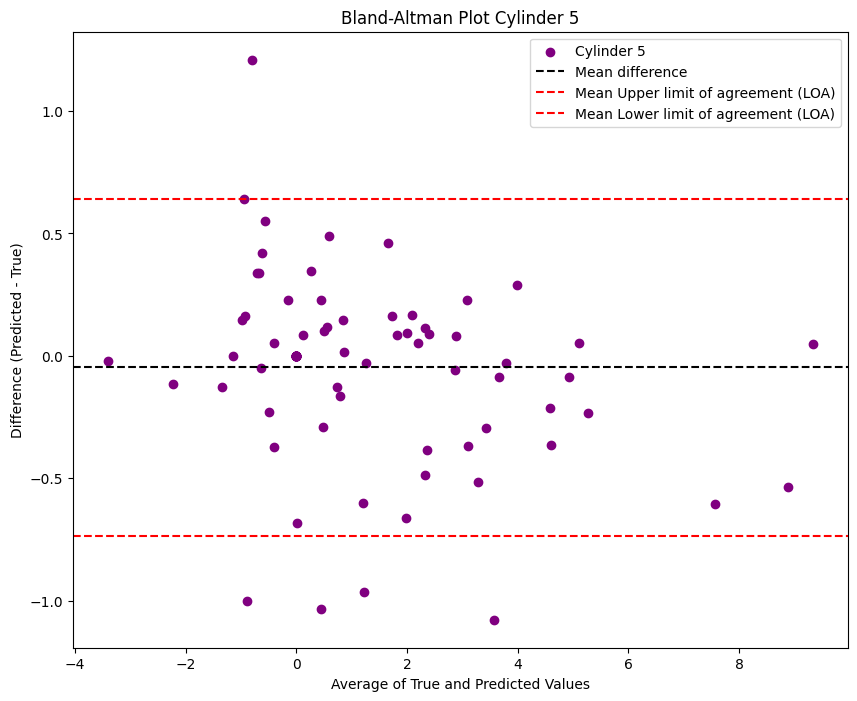

In [116]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_5'], differences['unet_difference_5'], color='purple', label='Cylinder 5')
plt.axhline(y=mean_difference5, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper5, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower5, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 5')
plt.legend()
plt.show()

In [117]:
print("Cylinder 1: ")
print("Mean Difference: ", mean_difference1)
print("Limits of Agreement: ", loa_upper1, loa_lower1)
print(loa_upper1 - mean_difference1)

print("Cylinder 2: ")
print("Mean Difference: ", mean_difference2)
print("Limits of Agreement: ", loa_upper2, loa_lower2)
print(loa_upper2 - mean_difference2)

print("Cylinder 3: ")
print("Mean Difference: ", mean_difference3)
print("Limits of Agreement: ", loa_upper3, loa_lower3)
print(loa_upper3 - mean_difference3)

print("Cylinder 4: ")
print("Mean Difference: ", mean_difference4)
print("Limits of Agreement: ", loa_upper4, loa_lower4)
print(loa_upper4 - mean_difference4)

print("Cylinder 5: ")
print("Mean Difference: ", mean_difference5)
print("Limits of Agreement: ", loa_upper5, loa_lower5)
print(loa_upper5 - mean_difference5)

print("Average: ")
print("Mean Difference: ", mean_difference)
print("Limits of Agreement: ", mean_loa_upper, mean_loa_lower)
print(mean_loa_upper - mean_difference)

Cylinder 1: 
Mean Difference:  -0.17479443387279087
Limits of Agreement:  1.0501893365005384 -1.3997782042461202
1.2249837703733293
Cylinder 2: 
Mean Difference:  -0.17640328648725961
Limits of Agreement:  1.1067868157699268 -1.4595933887444459
1.2831901022571863
Cylinder 3: 
Mean Difference:  0.001877599023728512
Limits of Agreement:  1.1717540446589698 -1.1679988466115128
1.1698764456352413
Cylinder 4: 
Mean Difference:  -0.04616644762673163
Limits of Agreement:  1.0259005440671214 -1.1182334393205846
1.072066991693853
Cylinder 5: 
Mean Difference:  -0.047209153687286946
Limits of Agreement:  0.6404819931824501 -0.734900300557024
0.6876911468697371
Average: 
Mean Difference:  -0.0885391445300681
Limits of Agreement:  0.9990225468358013 -1.1761008358959375
1.0875616913658694


In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import normalize

predictions_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/cylinder_niipredictions/'
raw_image_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/raw_images/'
mask_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/segmentations/'

raw_images = sorted(os.listdir(raw_image_directory))
predictions = sorted(os.listdir(predictions_directory))

unet_prediction_dataset = []
raw_image_dataset = []
segmentation_dataset = []
sliced_unet_prediction_dataset = []
sliced_raw_image_dataset = []
sliced_segmentation_dataset = []
image_sizes = []
image_names = []

for image_name in predictions:    
    if (image_name.split('.')[1] == 'nii'):
        base_name = image_name.split('.')[0]
        if base_name in filtered:
            image = nib.load(predictions_directory+image_name).get_fdata()
            raw = nib.load(raw_image_directory+image_name).get_fdata()
            segmentation = nib.load(mask_directory+image_name).get_fdata()
            unet_prediction_dataset.append(np.array(image))
            raw_image_dataset.append(np.array(raw))
            segmentation_dataset.append(np.array(segmentation))
            image_sizes.append(image.shape[2])
            image_names.append(image_name)

for i in range(len(unet_prediction_dataset)):
    for j in range(unet_prediction_dataset[i].shape[-1]):    
        middle = unet_prediction_dataset[i].shape[-1] // 2
        if j >= middle - 1 and j <= middle + 1:
            sliced_raw_image_dataset.append(raw_image_dataset[i][:,:,j])
            sliced_segmentation_dataset.append(segmentation_dataset[i][:,:,j])
            prediction = unet_prediction_dataset[i][:,:,:,:,j]
            prediction = prediction.squeeze(0)
            sliced_unet_prediction_dataset.append(prediction)

sliced_raw_image_dataset = np.array(sliced_raw_image_dataset)
sliced_segmentation_dataset = np.array(sliced_segmentation_dataset)

labelencoder = LabelEncoder()
n, h, w = sliced_segmentation_dataset.shape
sliced_masks_reshaped = sliced_segmentation_dataset.reshape(-1,1)
sliced_masks_reshaped_encoded = labelencoder.fit_transform(sliced_masks_reshaped)
sliced_masks_encoded_original_shape = sliced_masks_reshaped_encoded.reshape(n, h, w)

print(f'Labels: {np.unique(sliced_masks_encoded_original_shape)}')

sliced_image_dataset = np.expand_dims(sliced_raw_image_dataset, axis=3)
sliced_image_dataset = normalize(sliced_image_dataset, axis=1)

sliced_mask_dataset = np.expand_dims(sliced_masks_encoded_original_shape, axis=3)
sliced_mask_dataset = to_categorical(sliced_mask_dataset, 7)

NameError: name 'os' is not defined